In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sys
plt.rcParams['text.usetex'] = (sys.platform == "darwin")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
plt.rcParams['font.size'] = 9

MODEL_FILES = {
    # "functionxy": "../logs/graph_data_functionxy.json",
    # "functionexp4": "../logs/graph_data_functionexp4.json",
    "prosthetic": "../logs/graph_data_prosthetic.json",
    "pinnheat": "../logs/graph_data_pinnheat.json",
    "functionexp100": "../logs/graph_data_functionexp100.json",
    "acopf_ml4acopf": "../logs/graph_data_acopf_ml4acopf.json"
}

# MODEL_FILES = {
#     "prosthetic": "../logs/graph_data_prosthetic.json",
#     # "functionexp100": "../logs/graph_data_functionexp100.json",
# }

# MODEL_FILES = {
#     "functionbessel": "../logs/graph_data_functionbessel.json",
#     "funcellipeinc": "../logs/graph_data_funcellipeinc.json",
#     "funcellipkinc": "../logs/graph_data_funcellipkinc.json",
#     # "functionlegendre": "../logs/graph_data_functionlegendre.json",
#     "funcnoise": "../logs/graph_data_funcnoise.json"
# }

data = {}
segment_counts = None
input_widths = None

for name, fpath in MODEL_FILES.items():
    with open(fpath) as f:
        payload = json.load(f)
    segment_counts = payload["SEGMENT_COUNTS"]
    input_widths   = payload["INPUT_WIDTHS"]
    data[name]     = payload["graph_data"][name]

models     = sorted(data.keys(), key=lambda m: data[m]["n_params"])
size_tags  = {m: tag for m, tag in zip(models, ["Small", "Medium", "Medium-2", "Large"])}
labels     = {m: f"{size_tags[m]}: {m} ({data[m]['n_params']:,}p)" for m in models}
print("Loaded models (sorted by params):")
for m in models:
    print(f"  {size_tags[m]:6s}  {m}  ({data[m]['n_params']:,} params)")

Loaded models (sorted by params):
  Small   pinnheat  (420 params)
  Medium  functionexp100  (1,010 params)
  Medium-2  prosthetic  (3,616 params)
  Large   acopf_ml4acopf  (53,248 params)


## Graph 1 — Input Bound Width vs Output Bound Width
Log–log scale. Compares Opt and Vanilla across small / medium / large models.

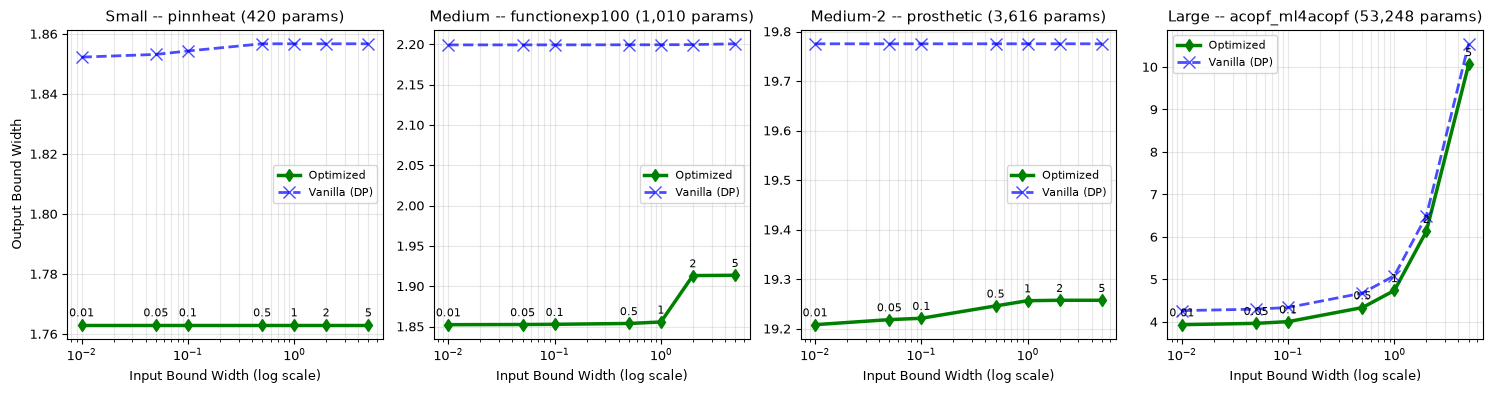

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, (ax, m) in enumerate(zip(axes, models)):
    d = data[m]
    iw_opt, ow_opt, _ = zip(*d["opt_input_sweep"])
    iw_van, ow_van, _ = zip(*d["van_input_sweep"])
    ax.plot(iw_opt, ow_opt, "d-",  color='green', lw=2.5, label="Optimized")
    ax.plot(iw_van, ow_van, "x--", color='blue', lw=2, alpha=0.7, markersize=8, label="Vanilla (DP)")
    for x, y in zip(iw_opt, ow_opt):
        ax.annotate(f"{x:g}", (x, y), textcoords="offset points", xytext=(0, 6), ha='center', fontsize=8, color='black')
    ax.set(xlabel="Input Bound Width (log scale)", title=f"{size_tags[m]} -- {m} ({data[m]['n_params']:,} params)", xscale='log')
    if i == 0:
        ax.set_ylabel("Output Bound Width")
    else:
        ax.set_ylabel("")
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot_input_vs_output_width_all_new.pdf", bbox_inches='tight', dpi=800)
plt.show()

## Graph 2 — Segments per Spline vs Output Bound Width
Shows tightening of output bounds as k grows, for each model size.

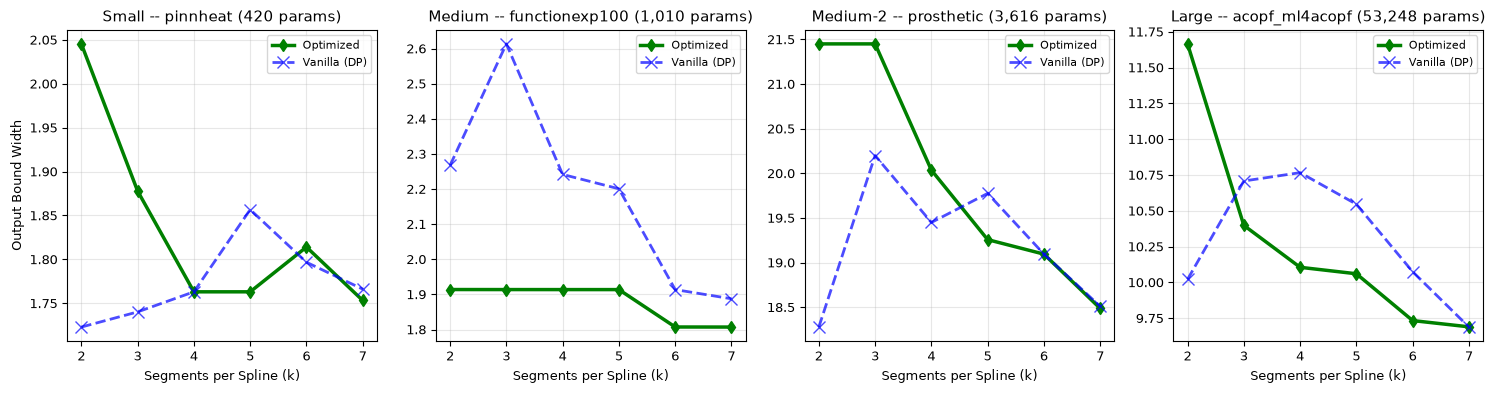

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, (ax, m) in enumerate(zip(axes, models)):
    d   = data[m]
    opt_widths = [w for (_, w) in d["opt_pareto"]]
    van_widths = [w for (_, w) in d["van_pareto"]]
    
    ax.plot(segment_counts, opt_widths, "d-",  color='green', lw=2.5, label="Optimized")
    ax.plot(segment_counts, van_widths, "x--", color='blue', lw=2, alpha=0.7, markersize=8, label="Vanilla (DP)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set(xlabel="Segments per Spline (k)", title=f"{size_tags[m]} -- {m} ({data[m]['n_params']:,} params)")
    if i == 0:
        ax.set_ylabel("Output Bound Width")
    else:
        ax.set_ylabel("")

# fig.suptitle("Segments per Spline vs Output Bound Width — Opt vs Vanilla", fontsize=13)
plt.tight_layout()
plt.savefig("plot_segments_vs_output_width_all_new.pdf", bbox_inches='tight', dpi=800)
plt.show()

## Timing Summary — Terminal Style

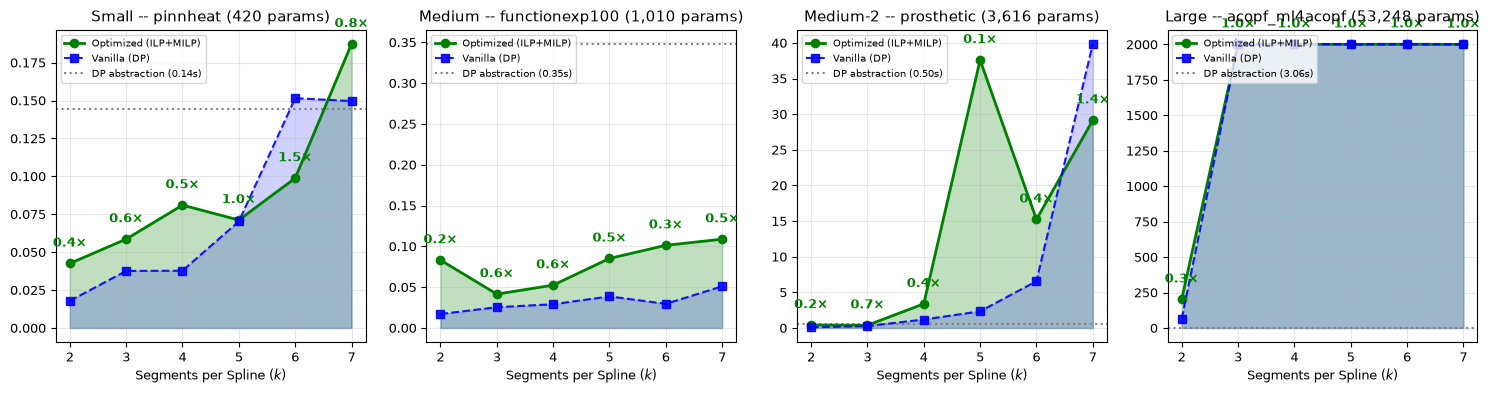

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True)
opt_color = 'green'
van_color = 'blue'
dp_color  = 'gray'

for col, m in enumerate(models):
    d         = data[m]
    tag       = size_tags[m]
    opt_total = [ilp + milp for ilp, milp in zip(d['ilp_time'], d['milp_time'])]
    van_total = d['van_time']
    speedup   = [vt / ot if ot > 0 else float('nan') for vt, ot in zip(van_total, opt_total)]

    ax = axes[col]

    # area fills
    ax.fill_between(segment_counts, opt_total, alpha=0.25, color=opt_color, zorder=1)
    ax.fill_between(segment_counts, van_total, alpha=0.18, color=van_color, zorder=1)

    # lines + markers on top
    ax.plot(segment_counts, opt_total, 'o-',  color=opt_color, lw=2,   label='Optimized (ILP+MILP)', zorder=3)
    ax.plot(segment_counts, van_total, 's--', color=van_color, lw=1.5, label='Vanilla (DP)', alpha=0.9, zorder=3)

    # one-time DP abstraction reference
    ax.axhline(d['dp_time'], color=dp_color, linestyle=':', lw=1.5, label=f'DP abstraction ({d["dp_time"]:.2f}s)')

    # speedup annotation above each Opt node
    for k, ot, s in zip(segment_counts, opt_total, speedup):
        if s == s:  # skip nan
            ax.annotate(f'{s:.1f}×', xy=(k, ot), xytext=(0, 10), textcoords='offset points', ha='center', va='bottom', fontsize=9, color=opt_color, fontweight='bold')

    # ax.set_title(f'{tag} -- {m} ({d["n_params"]:,} params)')
    # ax.set_xlabel('Segments per Spline ($k$)')
    # ax.set_ylabel('Time (s)')
    ax.set(xlabel="Segments per Spline ($k$)", title=f'{tag} -- {m} ({d["n_params"]:,} params)')
    if i == 0:
        ax.set_ylabel("Time (s)")
    else:
        ax.set_ylabel("")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper left')

# fig.suptitle('Verification Timing: Optimized vs Vanilla (DP)', fontsize=13)
plt.tight_layout()
plt.savefig('plot_timing_summary_all_new.pdf', bbox_inches='tight', dpi=800)
plt.show()

## LaTeX Timing Table

In [ ]:
def gen_latex_table(models, data, segment_counts):
    n_k = len(segment_counts)
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Verification timing breakdown across model sizes. "
                 r"DP abstraction is computed once per model; "
                 r"ILP allocation and MILP verification are per query.}")
    lines.append(r"\label{tab:timing}")
    lines.append(r"\small")
    lines.append(r"\begin{tabular}{llrrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Model & Size & $k$ & ILP (s) & MILP (s) & Opt Total (s) & Van (s) & Speedup \\")
    lines.append(r"\midrule")

    for idx, m in enumerate(models):
        d    = data[m]
        tag  = size_tags[m]
        npar = d['n_params']
        dp_t = d['dp_time']

        model_cell = rf"\texttt{{{m}}} ({npar:,}p) "
        model_cell += rf"[DP={dp_t:.2f}s]"

        for row_idx, (k, ilp_t, milp_t, van_t) in enumerate(zip(
                segment_counts, d['ilp_time'], d['milp_time'], d['van_time'])):
            opt_total = ilp_t + milp_t
            speedup   = van_t / opt_total if opt_total > 1e-6 else float('nan')

            if row_idx == 0:
                mc = rf"\multirow{{{n_k}}}{{*}}{{{model_cell}}}"
                sz = rf"\multirow{{{n_k}}}{{*}}{{{tag}}}"
            else:
                mc = ""
                sz = ""

            lines.append(
                f"  {mc} & {sz} & {k} "
                f"& {ilp_t:.3f} & {milp_t:.3f} "
                f"& {opt_total:.3f} & {van_t:.3f} "
                f"& {speedup:.2f}x \\\\"
            )

        if idx < len(models) - 1:
            lines.append(r"\midrule")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)


latex_str = gen_latex_table(models, data, segment_counts)
print(latex_str)

with open("timing_table.tex", "w") as f:
    f.write(latex_str)
print("\nSaved to timing_table.tex")